<a href="https://www.kaggle.com/code/atrbyg24/binary-classification-bank-dataset?scriptVersionId=258564443" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Import Libraries

In [38]:
import pandas as pd
import numpy as np
import warnings

import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.pipeline import make_pipeline, Pipeline
import optuna

import matplotlib.pyplot as plt
import seaborn as sns


warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")

%matplotlib inline

# Load datasets

In [39]:
train = pd.read_csv('/kaggle/input/playground-series-s5e8/train.csv',index_col = 'id')
test = pd.read_csv('/kaggle/input/playground-series-s5e8/test.csv',index_col = 'id')

# Exploratory Data analysis

In [40]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 750000 entries, 0 to 749999
Data columns (total 17 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   age        750000 non-null  int64 
 1   job        750000 non-null  object
 2   marital    750000 non-null  object
 3   education  750000 non-null  object
 4   default    750000 non-null  object
 5   balance    750000 non-null  int64 
 6   housing    750000 non-null  object
 7   loan       750000 non-null  object
 8   contact    750000 non-null  object
 9   day        750000 non-null  int64 
 10  month      750000 non-null  object
 11  duration   750000 non-null  int64 
 12  campaign   750000 non-null  int64 
 13  pdays      750000 non-null  int64 
 14  previous   750000 non-null  int64 
 15  poutcome   750000 non-null  object
 16  y          750000 non-null  int64 
dtypes: int64(8), object(9)
memory usage: 103.0+ MB


We do not have any missing values and there are total of 750,000 rows in our dataset.

In [41]:
train.describe()

,age,balance,day,duration,campaign,pdays,previous,y
count,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000
mean,40.926395,1204.067397,16.117209,256.229144,2.577008,22.412733,0.298545,0.120651
std,10.098829,2836.096759,8.250832,272.555662,2.718514,77.319998,1.335926,0.325721
min,18.000000,-8019.000000,1.000000,1.000000,1.000000,-1.000000,0.000000,0.000000
25%,33.000000,0.000000,9.000000,91.000000,1.000000,-1.000000,0.000000,0.000000
50%,39.000000,634.000000,17.000000,133.000000,2.000000,-1.000000,0.000000,0.000000
75%,48.000000,1390.000000,21.000000,361.000000,3.000000,-1.000000,0.000000,0.000000
max,95.000000,99717.000000,31.000000,4918.000000,63.000000,871.000000,200.000000,1.000000


We see that 'balance' and 'duration' both have large standard deviation. By looking at the 75 percentile and the max values, the distribution of these features might have long right tails and are unlikely to be normally distributed. 

In [42]:
train.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
id,,,,,,,,,,,,,,,,,
0,42,technician,married,secondary,no,7,no,no,cellular,25,aug,117,3,-1,0,unknown,0
1,38,blue-collar,married,secondary,no,514,no,no,unknown,18,jun,185,1,-1,0,unknown,0
2,36,blue-collar,married,secondary,no,602,yes,no,unknown,14,may,111,2,-1,0,unknown,0
3,27,student,single,secondary,no,34,yes,no,unknown,28,may,10,2,-1,0,unknown,0
4,26,technician,married,secondary,no,889,yes,no,cellular,3,feb,902,1,-1,0,unknown,1


In [43]:
num_cols = train.select_dtypes(include='number').columns.tolist()
cat_cols = train.select_dtypes(include = 'object').columns.tolist()

In [44]:
for col in cat_cols:
    print(f'\n {train[col].value_counts()}')


 job
management       175541
blue-collar      170498
technician       138107
admin.            81492
services          64209
retired           35185
self-employed     19020
entrepreneur      17718
unemployed        17634
housemaid         15912
student           11767
unknown            2917
Name: count, dtype: int64

 marital
married     480759
single      194834
divorced     74407
Name: count, dtype: int64

 education
secondary    401683
tertiary     227508
primary       99510
unknown       21299
Name: count, dtype: int64

 default
no     737151
yes     12849
Name: count, dtype: int64

 housing
yes    411288
no     338712
Name: count, dtype: int64

 loan
no     645023
yes    104977
Name: count, dtype: int64

 contact
cellular     486655
unknown      231627
telephone     31718
Name: count, dtype: int64

 month
may    228411
aug    128859
jul    110647
jun     93670
nov     66062
apr     41319
feb     37611
jan     18937
oct      9204
sep      7409
mar      5802
dec      2069
Name: co

Some of these features have a value of 'unknown'. It is unclear if these should be treated as a missing value or we should just leave it as is.

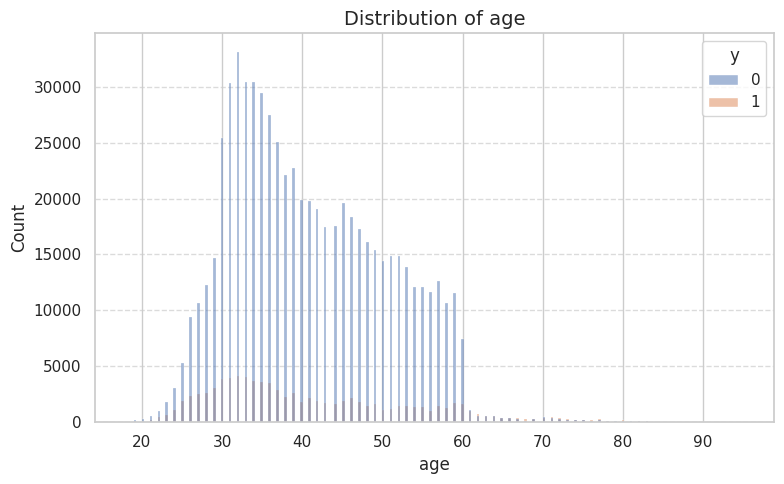

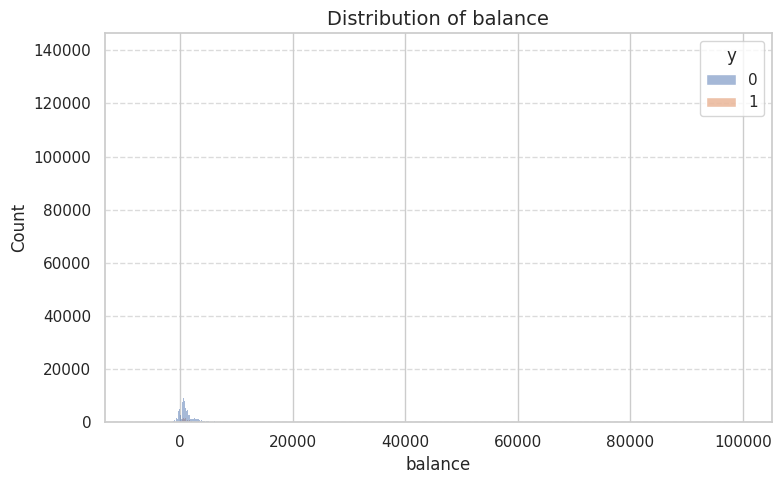

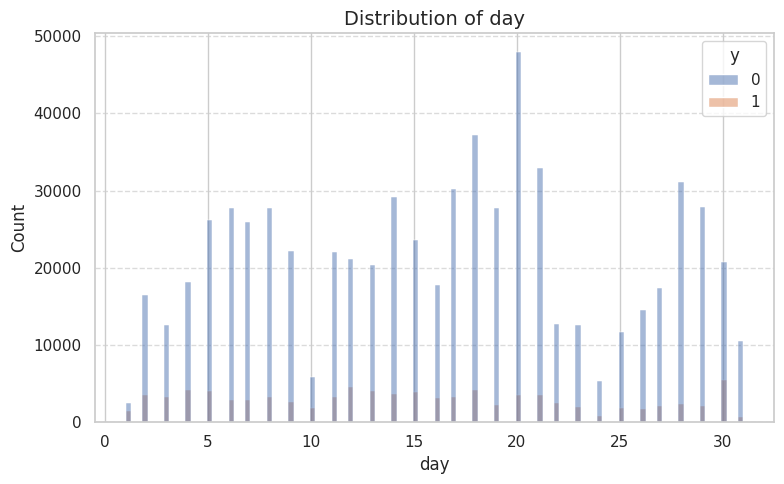

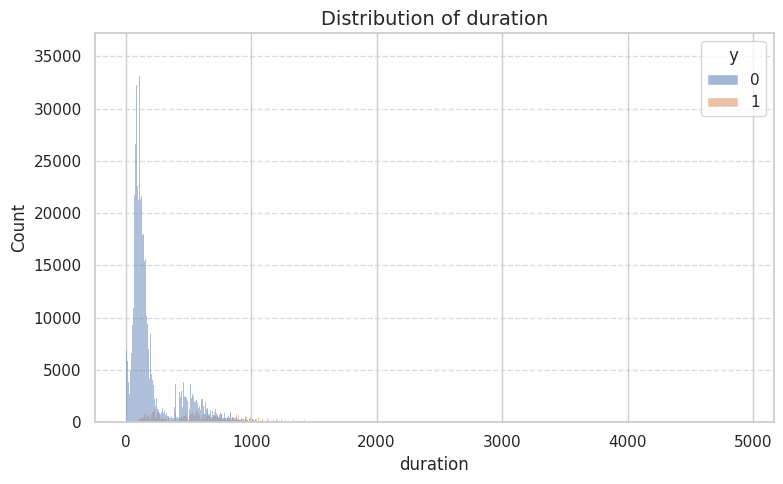

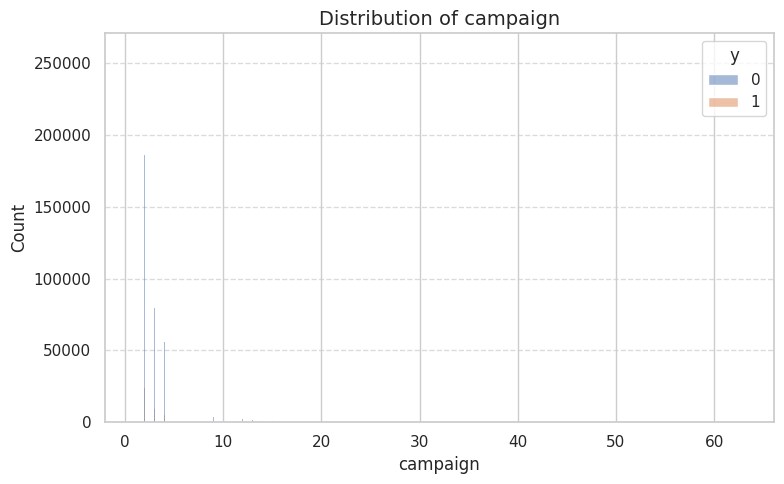

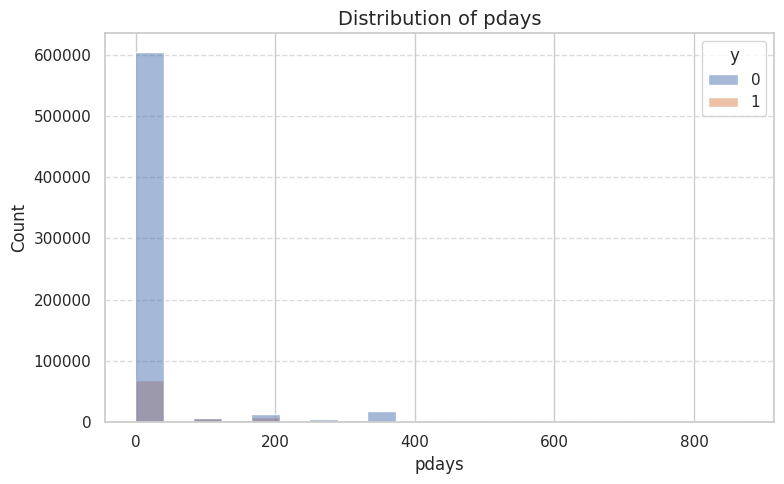

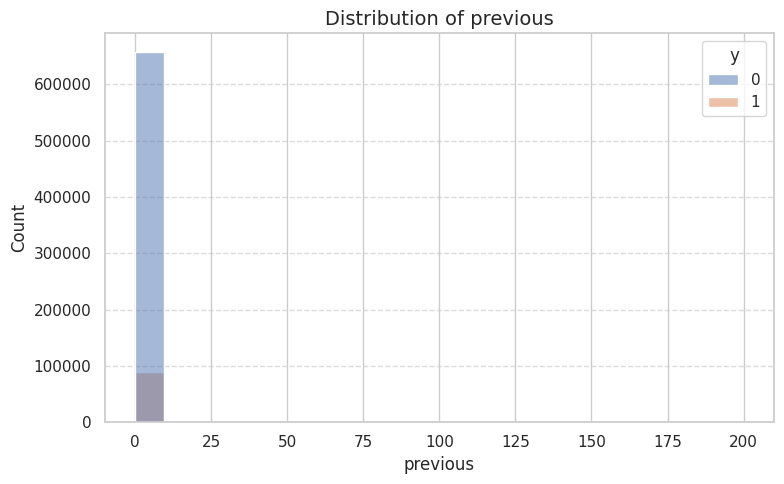

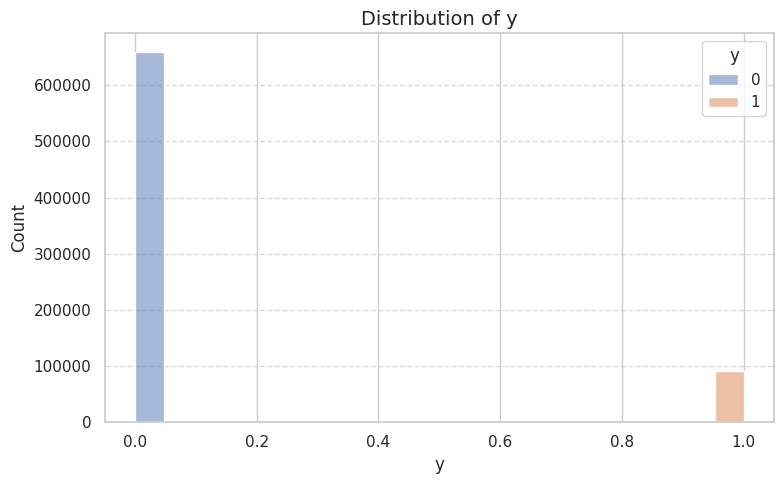

In [45]:
for col in num_cols:
    plt.figure(figsize=(8, 5))
    sns.histplot(data=train,x=col,hue='y')
    plt.title(f'Distribution of {col}', fontsize=14)
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Count', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

We see that the target feature is imbalanced with around a 6:1 ratio between 0 and 1 for 'y'.

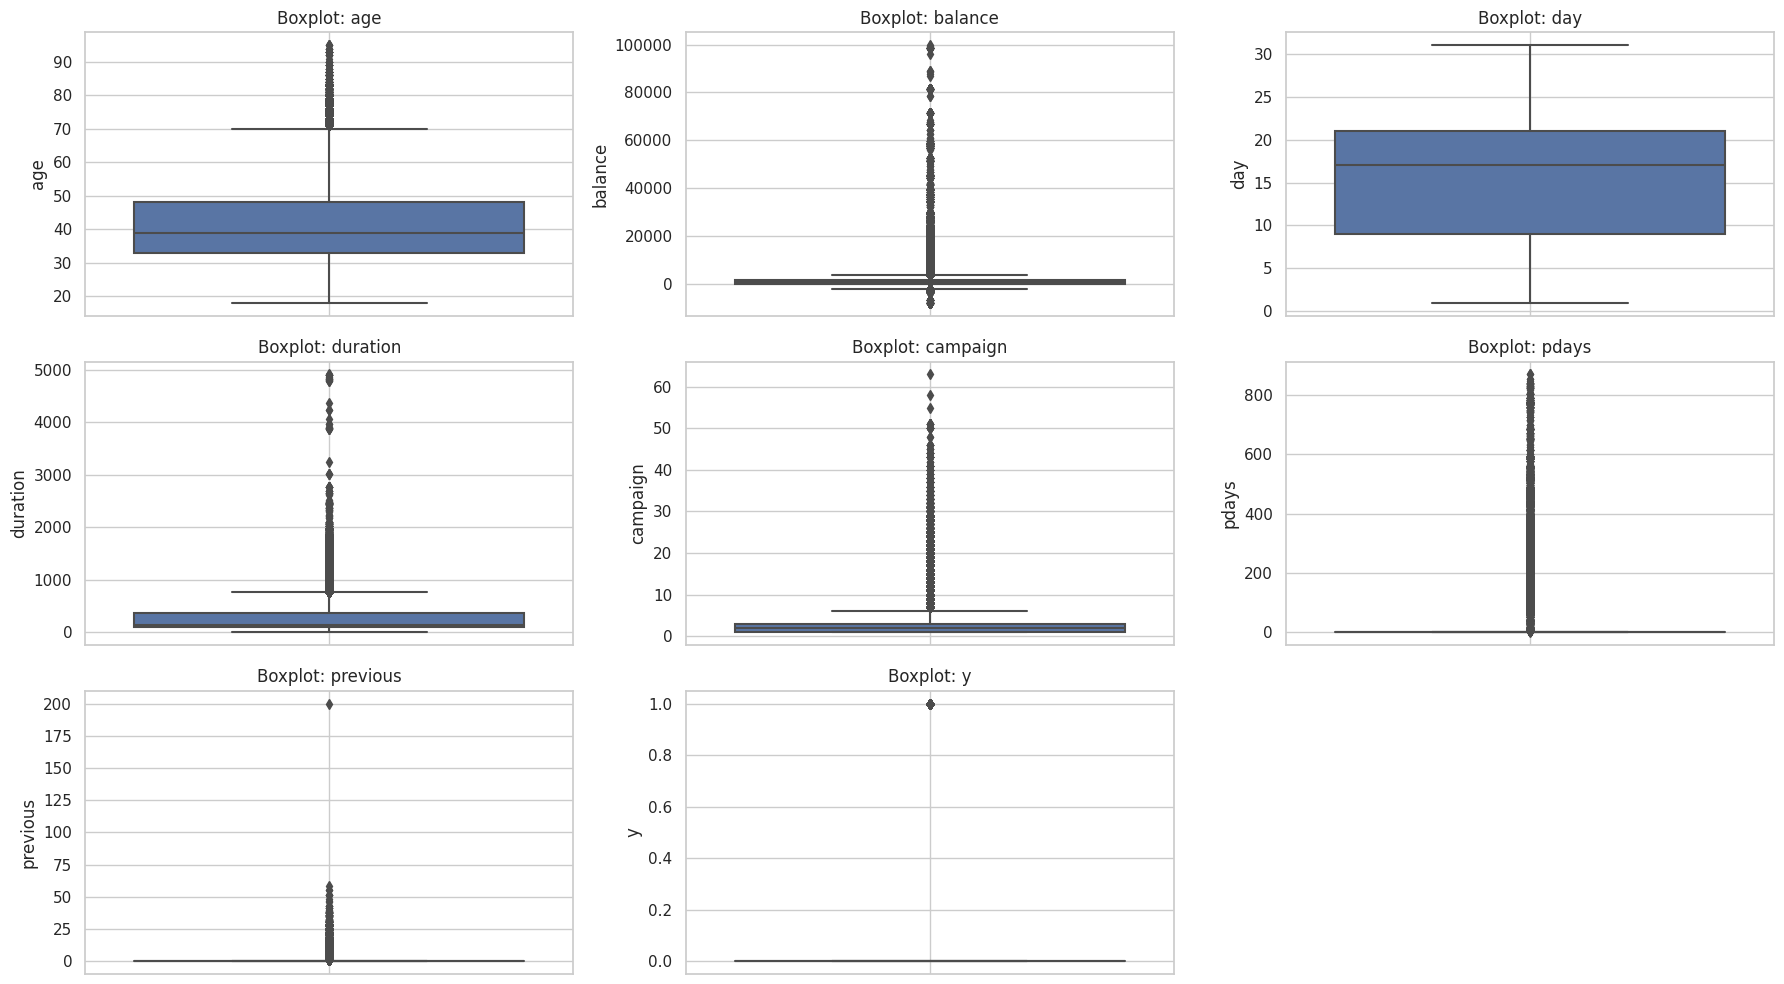

In [46]:
plt.figure(figsize=(18, 10))
for i, col in enumerate(num_cols):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(data=train, y=col)
    plt.title(f"Boxplot: {col}")
    plt.grid(True)
plt.tight_layout()
plt.show()

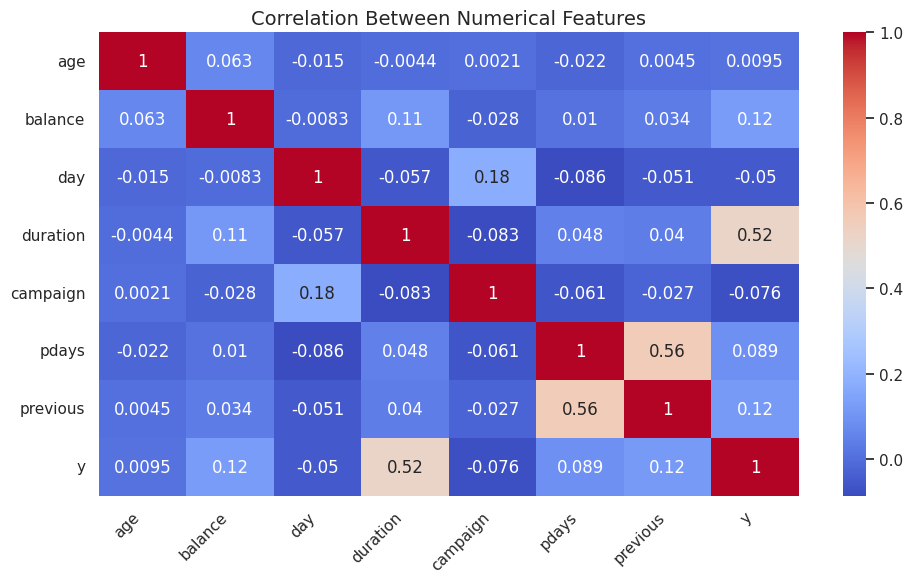

In [47]:
plt.figure(figsize=(10, 6))
sns.heatmap(
    train[num_cols].corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title("Correlation Between Numerical Features", fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Feature engineering and pipeline

In [48]:
cat_pipeline = make_pipeline(
    SimpleImputer(strategy='most_frequent'),
    OneHotEncoder()
)

log_pipeline = make_pipeline(
    SimpleImputer(strategy='median'),
    StandardScaler(),
    FunctionTransformer(np.log1p, feature_names_out='one-to-one'),
    StandardScaler()
)

default_num_pipeline = make_pipeline(
    SimpleImputer(strategy='median'),
    StandardScaler()
)

preprocessing = ColumnTransformer([
    ('log', log_pipeline, ['balance','duration','campaign']),
    ('cat', cat_pipeline, make_column_selector(dtype_include=object))
    ],
    remainder=default_num_pipeline)

model = Pipeline(steps=[
    ('preprocessor', preprocessing),
    ('scaler', StandardScaler()),
    ('classifier', XGBClassifier(objective = 'binary:logistic',eval_metric = 'auc',random_state=42))
])

In [49]:
X = train.drop('y', axis=1).copy()
y = train['y']
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, shuffle=True, random_state=17)

In [50]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                              SimpleImputer(strategy='median')),
                                                             ('standardscaler',
                                                              StandardScaler())]),
                                   transformers=[('log',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('standardscaler-1',
                                                                   StandardScaler()),
                                                                  ('functiontransformer',
                                                                   FunctionTransformer(feature_names_ou...
                               feature_types=None, gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, random_state=42, ...))])

# Baseline metrics

In [51]:
test_pred = model.predict_proba(X_test)[:,1]
test_labels = (test_pred > 0.5).astype(int)
accuracy = accuracy_score(y_test, test_labels)
roc_auc = roc_auc_score(y_test, test_pred)
print(f"Accuracy: {accuracy}")
print(f"ROC AUC Score: {roc_auc}")
print(classification_report(y_test, test_labels))

Accuracy: 0.93494
ROC AUC Score: 0.9664830286203034
              precision    recall  f1-score   support

           0       0.96      0.97      0.96    131899
           1       0.76      0.67      0.71     18101

    accuracy                           0.93    150000
   macro avg       0.86      0.82      0.84    150000
weighted avg       0.93      0.93      0.93    150000



# KFold Cross validation and Hyperparameter tuning with Optuna

In [56]:
def objective(trial):
    n_estimators = trial.suggest_int('n_estimators', 100, 1000)
    learning_rate = trial.suggest_float('learning_rate', 0.01, 0.02, log=True) 
    max_depth = trial.suggest_int('max_depth', 6, 9)
    subsample = trial.suggest_float('subsample', 0.7, 0.8) 
    colsample_bytree = trial.suggest_float('colsample_bytree', 0.9, 1.0)

    model = Pipeline(steps=[
    ('preprocessor', preprocessing),
    ('scaler', StandardScaler()),
    ('classifier', XGBClassifier(objective = 'binary:logistic',eval_metric = 'auc',random_state=42))
])

    scores = cross_val_score(model, X_train, y_train, cv=3, scoring='roc_auc')
    return scores.mean()

study = optuna.create_study(direction='maximize') 
study.optimize(objective, n_trials=5) 

print("Best trial:", study.best_trial)
best_xgb = Pipeline([
    ('preprocessor', preprocessing),
    ('scaler', StandardScaler()),
    ('classifier', XGBClassifier(**study.best_params, random_state=42))
])
best_xgb.fit(X_train, y_train)

[I 2025-08-27 20:32:03,650] A new study created in memory with name: no-name-a83272d1-5bd8-4328-a540-a08a7798e53d
[I 2025-08-27 20:32:31,404] Trial 0 finished with value: 0.9656285740872157 and parameters: {'n_estimators': 839, 'learning_rate': 0.016395520337765947, 'max_depth': 8, 'subsample': 0.7241956878951198, 'colsample_bytree': 0.9207426326776281}. Best is trial 0 with value: 0.9656285740872157.
[I 2025-08-27 20:32:58,592] Trial 1 finished with value: 0.9656285740872157 and parameters: {'n_estimators': 788, 'learning_rate': 0.011110187405590725, 'max_depth': 7, 'subsample': 0.7706056266606827, 'colsample_bytree': 0.9181592198991427}. Best is trial 0 with value: 0.9656285740872157.
[I 2025-08-27 20:33:26,189] Trial 2 finished with value: 0.9656285740872157 and parameters: {'n_estimators': 454, 'learning_rate': 0.013409973509687551, 'max_depth': 9, 'subsample': 0.7080367264966061, 'colsample_bytree': 0.925332362045696}. Best is trial 0 with value: 0.9656285740872157.
[I 2025-08-27 

Best trial: FrozenTrial(number=0, state=1, values=[0.9656285740872157], datetime_start=datetime.datetime(2025, 8, 27, 20, 32, 3, 652978), datetime_complete=datetime.datetime(2025, 8, 27, 20, 32, 31, 403944), params={'n_estimators': 839, 'learning_rate': 0.016395520337765947, 'max_depth': 8, 'subsample': 0.7241956878951198, 'colsample_bytree': 0.9207426326776281}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'n_estimators': IntDistribution(high=1000, log=False, low=100, step=1), 'learning_rate': FloatDistribution(high=0.02, log=True, low=0.01, step=None), 'max_depth': IntDistribution(high=9, log=False, low=6, step=1), 'subsample': FloatDistribution(high=0.8, log=False, low=0.7, step=None), 'colsample_bytree': FloatDistribution(high=1.0, log=False, low=0.9, step=None)}, trial_id=0, value=None)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                              SimpleImputer(strategy='median')),
                                                             ('standardscaler',
                                                              StandardScaler())]),
                                   transformers=[('log',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('standardscaler-1',
                                                                   StandardScaler()),
                                                                  ('functiontransformer',
                                                                   FunctionTransformer(feature_names_ou...
                               feature_types=None, gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None,
                               learning_rate=0.016395520337765947, max_bin=None,
                               max_cat_threshold=None, max_cat_to_onehot=None,
                               max_delta_step=None, max_depth=8,
                               max_leaves=None, min_child_weight=None,
                               missing=nan, monotone_constraints=None,
                               multi_strategy=None, n_estimators=839,
                               n_jobs=None, num_parallel_tree=None,
                               random_state=42, ...))])

In [57]:
submission = pd.read_csv("/kaggle/input/playground-series-s5e8/sample_submission.csv")
submission['y'] = best_xgb.predict_proba(test)[:,1]
submission.to_csv("submission.csv", index=False)